# Week 03 Assignment: Building the Transformer Encoder

**Course:** TECH 77 — Modern AI Architectures: From RNNs to Chatbots  
**Format:** Google Colab  
**Estimated Time:** 60–90 minutes

## Assignment Overview

In this assignment, you will explore the architectural components that turn self-attention into a Transformer encoder.

You will:

- Examine how positional information is added to token embeddings
- Generate and visualize sinusoidal positional encodings
- Explore residual connections
- Apply Layer Normalization
- Build a simple Transformer encoder classifier

This notebook focuses on the encoder and does not build a complete encoder–decoder Transformer.


## Learning Objectives

By the end of this assignment, you should be able to:

- Explain why Transformers need positional information
- Describe the basic pattern of sinusoidal positional encoding
- Explain how residual connections preserve information
- Describe the purpose of Layer Normalization
- Identify the main components of a Transformer encoder block
- Build a basic text classifier with a Transformer encoder


## Part 0: Setup


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import (
    Input,
    Embedding,
    MultiHeadAttention,
    LayerNormalization,
    Add,
    Dense,
    Dropout,
    GlobalAveragePooling1D
)
from tensorflow.keras.models import Model

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.21.0


## Part 1: Why Does a Transformer Need Position Information?

Self-attention can compare every token with every other token, but it does not automatically know the order in which tokens appear. Positional information is therefore added to token embeddings.

Consider these sentences:

> Dog bites man.  
> Man bites dog.

The sentences contain the same words, but their meanings are different because the word order changes.

### Question 1

Why might a Transformer without positional information struggle to distinguish these two sentences?

**Your answer:** It would struggle with the order of the words and the meaning they would bring. EX: cat eats food and food eats cat.

### Question 2

Why is token order especially important for tasks such as translation, sentiment analysis, or question answering?

**Your answer:** The order of the sentence changes the meaning of the sentence causing a biased sentiment analysis which would just be an incorrect representation of the actual dataset.Similarly it affects the transalation of these sentences as well as an example " Food eats man than man eats food" . Similarly misorentation of these token order could change the questions which directly affects the order.


## Part 2: Assign Token Positions


In [5]:
sentence = ["the", "cat", "sat", "on", "the", "mat"]

# TODO 1:
# Create a NumPy array containing the positions 0 through 5.

# YOUR CODE HERE
positions = np.arange(len(sentence))
position_table = pd.DataFrame({
    "Token": sentence,
    "Position": positions
})

position_table


,Token,Position
0,the,0
1,cat,1
2,sat,2
3,on,3
4,the,4
5,mat,5


### Question 3

If the same word appears at two different positions, such as **the** in the example above, should its complete input representation be identical at both positions? Explain.

**Your answer:** No! If we were using the discrete representation of these words then probably yes but since we use relative positional representation using sinusodial functions it should have different positional encoding.


## Part 3: Generate Sinusoidal Positional Encodings

The original Transformer uses sine and cosine functions to create fixed positional encodings.

For position \(pos\) and embedding dimension \(i\):

\[
PE(pos, 2i) = \sin\left(\frac{pos}{10000^{2i/d_{model}}}\right)
\]

\[
PE(pos, 2i+1) = \cos\left(\frac{pos}{10000^{2i/d_{model}}}\right)
\]

You do not need to memorize these equations. Focus on how they create a distinct pattern for each position.


In [7]:
def create_positional_encoding(sequence_length, embedding_dim):
    position = np.arange(sequence_length)[:, np.newaxis]
    dimension = np.arange(embedding_dim)[np.newaxis, :]

    angle_rates = 1 / np.power(
        10000,
        (2 * (dimension // 2)) / np.float32(embedding_dim)
    )
    angle_radians = position * angle_rates

    positional_encoding = np.zeros((sequence_length, embedding_dim))

    # TODO 2:
    # Apply sine to the even-numbered dimensions.
    # Hint: use angle_radians[:, 0::2]

    # YOUR CODE HERE
    positional_encoding[:, 0::2] = np.sin(angle_radians[:, 0::2])

    # TODO 3:
    # Apply cosine to the odd-numbered dimensions.
    # Hint: use angle_radians[:, 1::2]

    # YOUR CODE HERE
    positional_encoding[:, 1::2] = np.cos(angle_radians[:, 1::2])
    return positional_encoding


sequence_length = 20
embedding_dim = 32

positional_encoding = create_positional_encoding(
    sequence_length,
    embedding_dim
)

print("Positional encoding shape:", positional_encoding.shape)
print(np.round(positional_encoding[:3, :6], 3))


Positional encoding shape: (20, 32)
[[ 0.     1.     0.     1.     0.     1.   ]
 [ 0.841  0.54   0.533  0.846  0.311  0.95 ]
 [ 0.909 -0.416  0.902  0.431  0.591  0.807]]


## Part 4: Visualize Positional Encodings


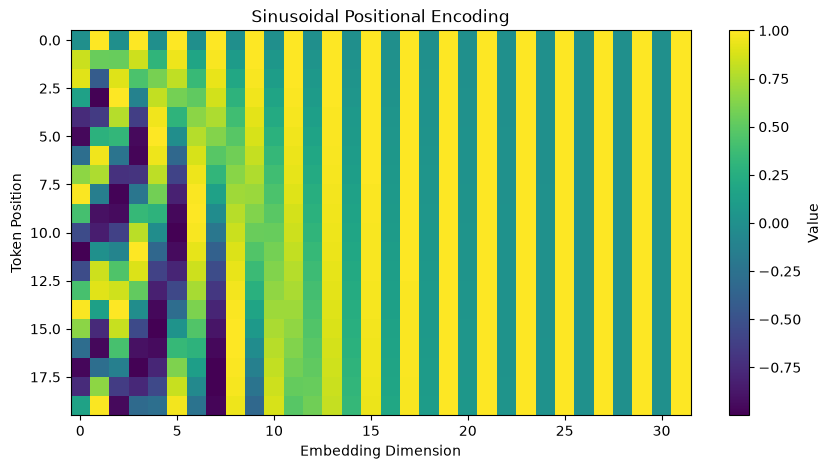

In [8]:
# TODO 4:
# Display positional_encoding as a heatmap using plt.imshow().
# Add a color bar and appropriate axis labels.

plt.figure(figsize=(10, 5))

# YOUR CODE HERE
plt.imshow(positional_encoding, cmap='viridis', aspect='auto')
plt.colorbar(label="Value")
plt.xlabel("Embedding Dimension")
plt.ylabel("Token Position")
plt.title("Sinusoidal Positional Encoding")
plt.show()


### Question 4

What patterns do you observe in the positional-encoding heatmap?

**Your answer:**  I observe a mosaic pattern where until dimension 9 there have been mixed representations of the token positions from 1.00 to 0.75 and it eventually fades away.

### Question 5

Why might using several sine and cosine frequencies be more useful than assigning each token a single position number?

**Your answer:** This would help bounded values which are between -1 and 1. The usage of sine and cosine could be used for varying multiple frequencies giving raise to multiple combinations of positions. This would also help the vector to not blow up from 1-> infinity which would shoot up the learning weights . Its easier to determine the position and position+k. 


## Part 5: Add Position Information to Embeddings

A Transformer normally adds positional encodings to token embeddings:

\[
\text{Transformer Input} = \text{Token Embedding} + \text{Positional Encoding}
\]

Both arrays must have the same shape.


In [9]:
token_embeddings = np.array([
    [0.2, 0.5, 0.1, 0.7],
    [0.6, 0.1, 0.4, 0.3],
    [0.3, 0.8, 0.2, 0.5]
])

small_position_encoding = create_positional_encoding(
    sequence_length=3,
    embedding_dim=4
)

# TODO 5:
# Add the positional encodings to the token embeddings.

# YOUR CODE HERE
combined_embeddings = token_embeddings + small_position_encoding
print("Token embeddings:")
print(np.round(token_embeddings, 3))

print("\nPositional encodings:")
print(np.round(small_position_encoding, 3))

print("\nCombined representations:")
print(np.round(combined_embeddings, 3))


Token embeddings:
[[0.2 0.5 0.1 0.7]
 [0.6 0.1 0.4 0.3]
 [0.3 0.8 0.2 0.5]]

Positional encodings:
[[ 0.     1.     0.     1.   ]
 [ 0.841  0.54   0.01   1.   ]
 [ 0.909 -0.416  0.02   1.   ]]

Combined representations:
[[0.2   1.5   0.1   1.7  ]
 [1.441 0.64  0.41  1.3  ]
 [1.209 0.384 0.22  1.5  ]]


### Question 6

Why can token embeddings and positional encodings be added directly?

**Your answer:** Since positional encoding are bounded between -1 to 1 adding them would contain them in the same vector size of the token embedding. If we concatinate them then we would have to scale up the system for increased vector size.


## Part 6: Residual Connections

A residual connection adds the input of a sublayer back to its output:

\[
\text{Residual Output} = x + F(x)
\]

Here, \(x\) is the original input and \(F(x)\) is the transformed representation.


In [10]:
x = np.array([
    [1.0, 0.5, -0.2, 0.8],
    [0.3, -0.1, 0.7, 0.4]
])

f_x = np.array([
    [0.2, -0.3, 0.4, 0.1],
    [-0.1, 0.2, 0.1, 0.3]
])

# TODO 6:
# Compute the residual output.

# YOUR CODE HERE
residual_output = x + f_x
print("Original input:")
print(x)

print("\nTransformed representation:")
print(f_x)

print("\nResidual output:")
print(residual_output)


Original input:
[[ 1.   0.5 -0.2  0.8]
 [ 0.3 -0.1  0.7  0.4]]

Transformed representation:
[[ 0.2 -0.3  0.4  0.1]
 [-0.1  0.2  0.1  0.3]]

Residual output:
[[1.2 0.2 0.2 0.9]
 [0.2 0.1 0.8 0.7]]


### Question 7

How does the residual connection preserve information from the original input?

**Your answer:** Since each sublayer would have access to previous sublayer's output , if any of the sublayer learns poorly then that information is gone. With x + f_x , even if f_x learns something imperfect then x still directly presents in the output.

### Question 8

Why must \(x\) and \(F(x)\) have compatible shapes?

**Your answer:** This is a design constraint on the sublayer itself, f_x has to be built to output the same shape as the input inorder for the residual connection to be possible.


## Part 7: Apply Layer Normalization


In [11]:
sample_batch = np.array([
    [2.0, 4.0, 6.0, 8.0],
    [1.0, 3.0, 5.0, 7.0]
], dtype=np.float32)

layer_norm = LayerNormalization(epsilon=1e-6)

# TODO 7:
# Apply layer_norm to sample_batch.

# YOUR CODE HERE
normalized_batch = layer_norm(sample_batch)
print("Original values:")
print(sample_batch)

print("\nNormalized values:")
print(np.round(normalized_batch.numpy(), 3))

print("\nMean of each normalized row:")
print(np.round(np.mean(normalized_batch.numpy(), axis=-1), 3))

print("\nStandard deviation of each normalized row:")
print(np.round(np.std(normalized_batch.numpy(), axis=-1), 3))


Original values:
[[2. 4. 6. 8.]
 [1. 3. 5. 7.]]

Normalized values:
[[-1.342 -0.447  0.447  1.342]
 [-1.342 -0.447  0.447  1.342]]

Mean of each normalized row:
[-0.  0.]

Standard deviation of each normalized row:
[1. 1.]


### Question 9

What happens to the approximate mean and standard deviation of each row after Layer Normalization?

**Your answer:** After the normalizatopn mean of each normalized row approximately becomes 0 and every row's standard deviation becomes approximately 1.

### Question 10

Why is Layer Normalization useful when training deep Transformer models?

**Your answer:** It prevents activations from exploding or shrinking as they pass through many stacked layers. Having a vertical normalization would shoot up the values as the mean would get biased therefore row/layer normalization would work better in preventing activations from exploding.


## Part 8: Build a Simple Transformer Encoder Classifier

We will now build a sentiment classifier using the IMDb movie review dataset.

The model will include:

- Token embeddings
- Learned positional embeddings
- Multi-head self-attention
- A residual connection and Layer Normalization
- A feed-forward network
- A second residual connection and Layer Normalization
- A pooling layer and classification output

This is a small educational model rather than a production Transformer.


In [12]:
vocab_size = 5000
max_len = 100

(x_train, y_train), (x_test, y_test) = imdb.load_data(
    num_words=vocab_size
)

# Use smaller subsets to keep training fast
x_train = x_train[:10000]
y_train = y_train[:10000]

x_test = x_test[:3000]
y_test = y_test[:3000]

# TODO 8:
# Pad the training and testing sequences.
# Use padding="post" and truncating="post".

# YOUR CODE HERE
x_train_padded = pad_sequences(x_train, maxlen=max_len, padding="post", truncating="post")
x_test_padded = pad_sequences(x_test, maxlen=max_len, padding="post", truncating="post")
print("Training shape:", x_train_padded.shape)
print("Testing shape:", x_test_padded.shape)


Training shape: (10000, 100)
Testing shape: (3000, 100)


In [13]:
embedding_dim = 32
num_heads = 2
key_dim = 16
ff_dim = 64

inputs = Input(shape=(max_len,))

# Token embeddings
token_embedding_layer = Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim
)
token_embeddings = token_embedding_layer(inputs)

# Learned positional embeddings
positions = tf.range(start=0, limit=max_len, delta=1)
position_embedding_layer = Embedding(
    input_dim=max_len,
    output_dim=embedding_dim
)
position_embeddings = position_embedding_layer(positions)

# TODO 9:
# Add token_embeddings and position_embeddings.

# YOUR CODE HERE
# TODO 9
x = token_embeddings + position_embeddings
# TODO 10:
# Apply MultiHeadAttention using x as query and value.

# YOUR CODE HERE
# TODO 10
attention_output = MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)(x, x)
# TODO 11:
# Add the first residual connection and Layer Normalization.
# Hint: Add()([x, attention_output])

# YOUR CODE HERE
# TODO 11
x = Add()([x, attention_output])
x = LayerNormalization(epsilon=1e-6)(x)
# Feed-forward network
ffn_output = Dense(ff_dim, activation="relu")(x)
ffn_output = Dense(embedding_dim)(ffn_output)

# TODO 12:
# Add the second residual connection and Layer Normalization.

# YOUR CODE HERE
# TODO 12
x = Add()([x, ffn_output])
x = LayerNormalization(epsilon=1e-6)(x)

x = GlobalAveragePooling1D()(x)
x = Dropout(0.2)(x)
x = Dense(32, activation="relu")(x)
outputs = Dense(1, activation="sigmoid")(x)

model = Model(inputs=inputs, outputs=outputs)

# TODO 13:
# Compile the model using:
# optimizer="adam"
# loss="binary_crossentropy"
# metrics=["accuracy"]

# YOUR CODE HERE
# TODO 13
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 100, 32)   │    160,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 100, 32)   │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 100, 32)   │      4,224 │ add[0][0],        │
│ (MultiHeadAttentio… │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 100, 32)   │          0 │ add[0][0],        │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 100, 32)   │         64 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 100, 64)   │      2,112 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 100, 32)   │      2,080 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 100, 32)   │          0 │ layer_normalizat… │
│                     │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 100, 32)   │         64 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      1,056 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         33 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 169,633 (662.63 KB)

 Trainable params: 169,633 (662.63 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
history = model.fit(
    x_train_padded,
    y_train,
    epochs=2,
    batch_size=64,
    validation_split=0.2
)


Epoch 1/2
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.6939 - loss: 0.5646 - val_accuracy: 0.8005 - val_loss: 0.4278
Epoch 2/2
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.8366 - loss: 0.3690 - val_accuracy: 0.7985 - val_loss: 0.4554


In [15]:
# TODO 14:
# Evaluate the model on the test set.

# YOUR CODE HERE
# TODO 14
test_loss, test_accuracy = model.evaluate(x_test_padded, y_test)
print("Test accuracy:", test_accuracy)

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7997 - loss: 0.4712
Test accuracy: 0.7996666431427002


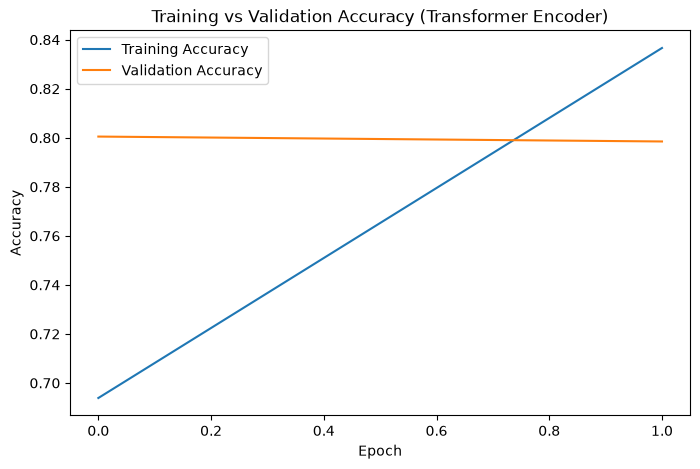

In [16]:
# TODO 15:
# Plot training accuracy and validation accuracy.

# YOUR CODE HERE
# TODO 15
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy (Transformer Encoder)")
plt.legend()
plt.show()

## Final Reflection

Answer each question in 2–4 sentences.

### 1. Why does self-attention still require positional information?

**Your answer:** Without the position markers, sentences with identical words but opposite meaning produce similar representations.

### 2. How do residual connections help information move through a deep network?

**Your answer:** information from the token embedding has to survive with multiple layers like self attention,FNN layer after layer with no guaranteed path back to original signal . Both forward representation and backward gradiant would be at risk of degrading depth.  Residual connections make the original signal stay through throughout all these hidden layers.

### 3. What role does Layer Normalization play in a Transformer encoder?

**Your answer:** Its role is to stabilize the representation at two exact points in each encoder block. As the residual connections shoot up the values by adding the input to the function . The layer normalization would stabilize it by resetting them to a mean of 0 and standard deviation of 1.

### 4. What happens inside the feed-forward network after self-attention?

**Your answer:** The feed-forward network performs two main tasks:
Non-linear Transformation: Self-attention provides context-aware representations of the input. The feed-forward network adds another layer of complexity by applying non-linear functions to these representations. It applies to each context aware token converted from position-embedded attention value to enrich it with non-linear representation.
Feature Enhancement: The feed-forward network can also be seen as a way to refine the features extracted by the self-attention layer. It can emphasize important features and suppress less relevant ones, making the final output more informative.

### 5. How is the model in this assignment more complete than the attention-based model from Week 02?

**Your answer:** Compared to the week 02 this model has an additional layers of positional embedding , FeedForward Neural Network , residual connection and layer normalization and form an encoder classifier.


## Submission Checklist

Before submitting, make sure your notebook includes:

- Token-position table
- Completed sinusoidal positional-encoding function
- Positional-encoding heatmap
- Combined token and positional embeddings
- Residual-connection output
- Layer-normalized values
- Padded IMDb sequences
- Completed Transformer encoder model
- Test accuracy
- Training and validation accuracy plot
- Answers to all questions and reflections
